# Wind Resource Analysis in Ireland

Final project for the **Programming for Data Analytics** module.

In this notebook I analyse hourly wind speed data from Met Éireann weather
stations in Ireland to explore how suitable different locations might be for
**wind energy (wind farms)**.

## 1. Introduction and Data Sources
## 2. Imports and Settings
## 3. Data Loading and Cleaning
## 4. Exploratory Analysis (Wind Speed Patterns)
## 5. Simple Wind Power Estimation
## 6. Trend Analysis / Modelling
## 7. Conclusions
## 8. Research Notes and References

## 1. Introduction and Data Sources

The aim of this project is to explore **wind resources in Ireland** using historic
hourly observations from Met Éireann weather stations.

In particular, I want to:

- understand the **distribution of wind speeds** at an Irish station,
- see how wind speed varies by **time of day** and **time of year**,
- build simple **aggregated datasets** (daily and monthly),
- and use a basic model to estimate **potential wind power output**.

For this project I will start with the hourly climate data for:

- **Knock Airport (station 4935)** – hourly observations including wind speed.

The data is available as a CSV file from Met Éireann’s climate data service:

- `https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv`

Later in the notebook I create additional derived datasets (daily and monthly
aggregations) from this raw hourly data and use them for the analysis.

In [3]:
# 2. Imports and Settings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: we may use scikit-learn later for simple trend analysis
from sklearn.linear_model import LinearRegression

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", None)

In [4]:
# 3. Data Loading and Cleaning

# URL for Knock Airport (station 4935) hourly data
KNOCK_URL = "https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv"

def load_knock_hourly_wind(url=KNOCK_URL, skiprows=23):
    """
    Load hourly climate data for Knock Airport from Met Éireann.

    Steps:
    - skip the metadata lines at the top of the file
    - parse the 'date' column as a datetime
    - set 'date' as the index
    - ensure the windspeed column ('wdsp') is numeric
    """
    # Read the CSV, skipping the 23-line metadata header
    df = pd.read_csv(url, skiprows=skiprows)

    # Parse date column (format like '10-apr-1996 14:00')
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    # Sort and set datetime index
    df = df.sort_values("date").set_index("date")

    # Convert windspeed column to numeric (coerce any bad values to NaN)
    df["wdsp"] = pd.to_numeric(df["wdsp"], errors="coerce")

    return df

# Load the data
knock = load_knock_hourly_wind()

print("Knock dataframe shape:", knock.shape)
knock[["temp", "wdsp"]].head()

/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_42235/3148544603.py:17: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, skiprows=skiprows)
/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_42235/3148544603.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True)


Knock dataframe shape: (257898, 20)


,temp,wdsp
date,,
1996-04-10 14:00:00,11.5,0.0
1996-07-31 08:00:00,11.5,0.0
1996-07-31 09:00:00,11.6,0.0
1996-07-31 10:00:00,12.9,0.0
1996-07-31 11:00:00,14.5,0.0


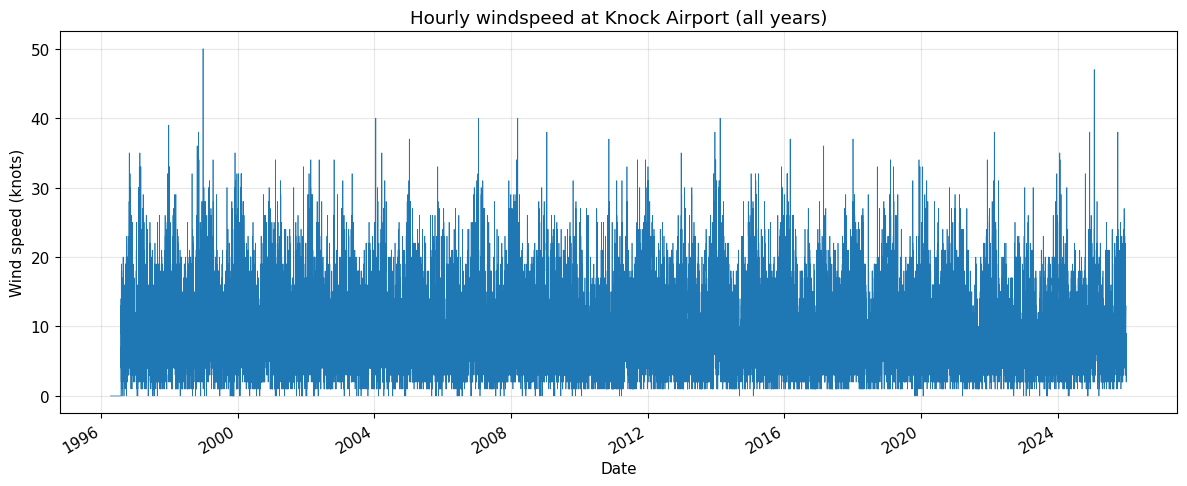

In [5]:
# Quick sanity check plot: hourly windspeed at Knock

plt.figure()
knock["wdsp"].plot(linewidth=0.5)
plt.title("Hourly windspeed at Knock Airport (all years)")
plt.xlabel("Date")
plt.ylabel("Wind speed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Create daily and monthly aggregated windspeed datasets

# Daily stats: mean, max and min windspeed per day
daily_wind = knock["wdsp"].resample("D").agg(["mean", "max", "min"])

# Monthly stats: mean and max windspeed per month
monthly_wind = knock["wdsp"].resample("M").agg(["mean", "max"])

print("Daily wind shape:", daily_wind.shape)
print("Monthly wind shape:", monthly_wind.shape)

daily_wind.head(), monthly_wind.head()

Daily wind shape: (10859, 3)
Monthly wind shape: (358, 2)


/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_42235/2076942827.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_wind = knock["wdsp"].resample("M").agg(["mean", "max"])


(            mean  max  min
 date                      
 1996-04-10   0.0  0.0  0.0
 1996-04-11   NaN  NaN  NaN
 1996-04-12   NaN  NaN  NaN
 1996-04-13   NaN  NaN  NaN
 1996-04-14   NaN  NaN  NaN,
                 mean   max
 date                      
 1996-04-30  0.000000   0.0
 1996-05-31       NaN   NaN
 1996-06-30       NaN   NaN
 1996-07-31  0.000000   0.0
 1996-08-31  8.397039  20.0)

## 4. Exploratory Analysis (Wind Speed Patterns)

In this section I explore the main patterns in windspeed at Knock Airport:

- how windspeed behaves over time (daily and monthly scales),
- the overall distribution of wind speeds,
- and simple seasonal patterns.

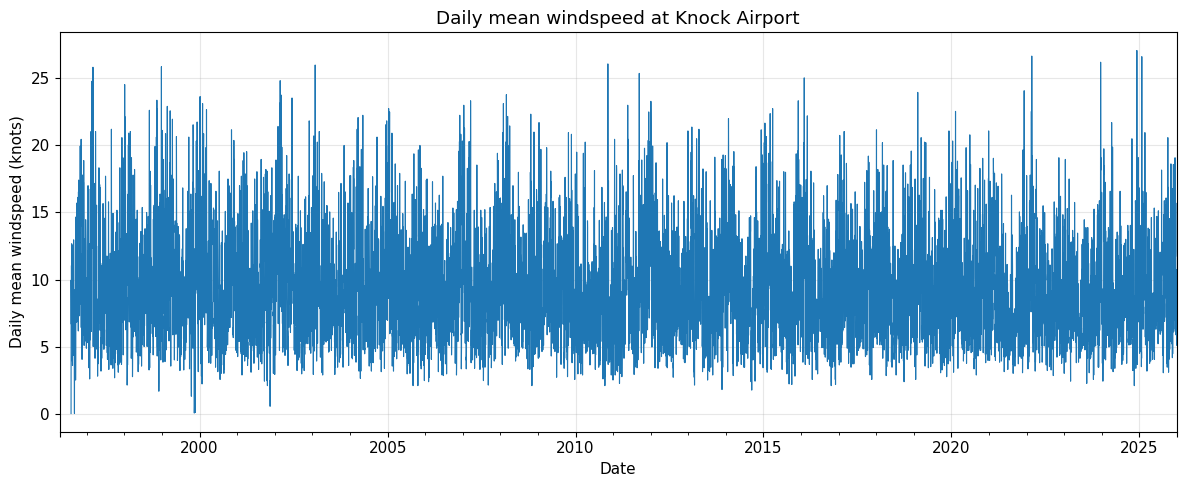

In [7]:
# Daily mean windspeed at Knock

plt.figure()
daily_wind["mean"].plot(linewidth=0.8)
plt.title("Daily mean windspeed at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Daily mean windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

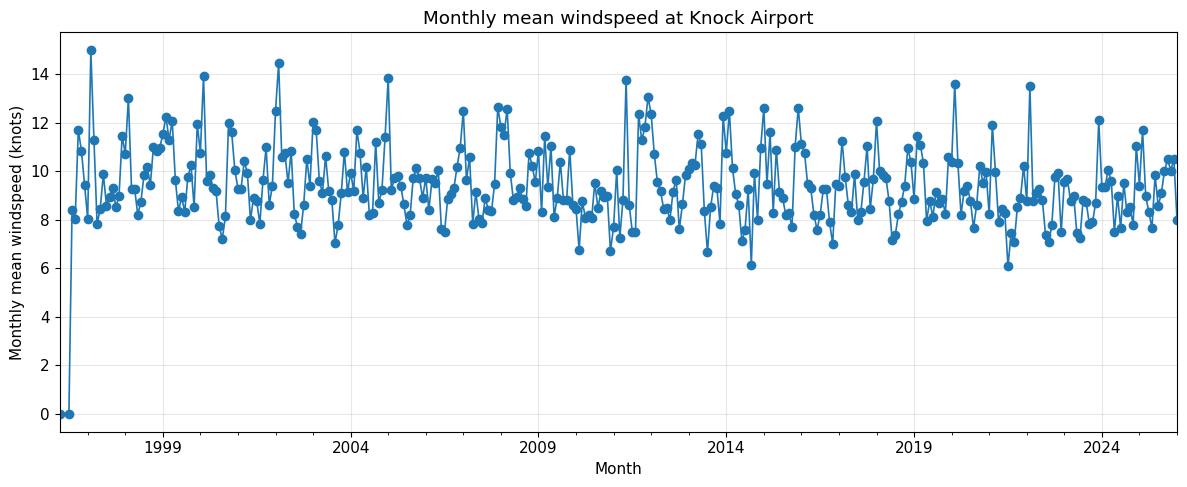

In [8]:
# Monthly mean windspeed at Knock

plt.figure()
monthly_wind["mean"].plot(marker="o", linewidth=1.2)
plt.title("Monthly mean windspeed at Knock Airport")
plt.xlabel("Month")
plt.ylabel("Monthly mean windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

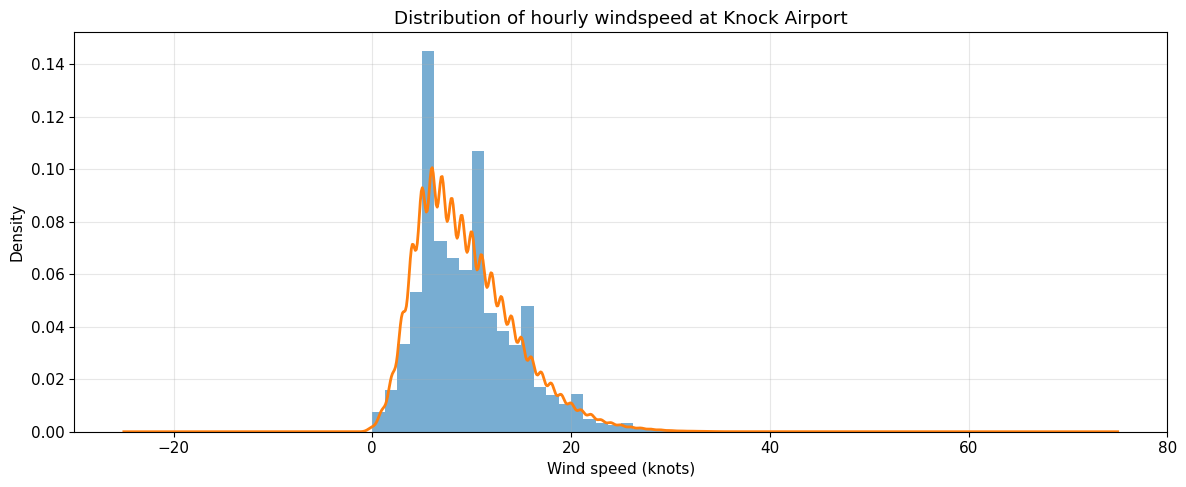

In [9]:
# Distribution of hourly windspeed (raw hourly data)

plt.figure()
knock["wdsp"].plot.hist(
    bins=40,
    density=True,
    alpha=0.6
)
knock["wdsp"].plot.kde(linewidth=2)

plt.title("Distribution of hourly windspeed at Knock Airport")
plt.xlabel("Wind speed (knots)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Seasonal patterns

To understand seasonality better I look at:

- the **average windspeed for each month of the year**, and
- the **average windspeed for each hour of the day**.

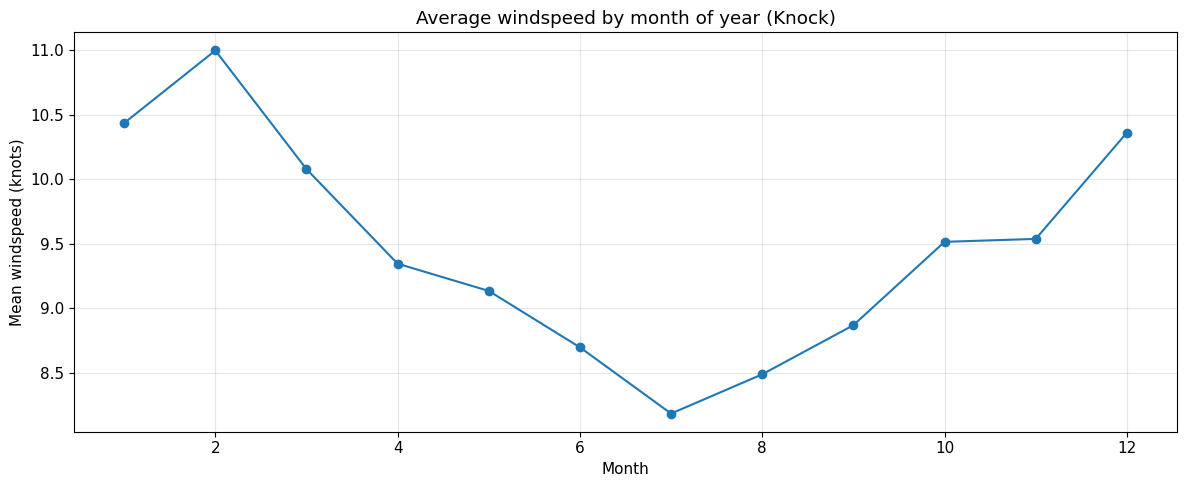

month
1     10.436669
2     10.999339
3     10.079533
4      9.346248
5      9.135150
6      8.697749
7      8.184328
8      8.488642
9      8.869577
10     9.515711
11     9.538576
12    10.361918
Name: wdsp, dtype: float64

In [10]:
# Add helper columns for month and hour of day
knock["month"] = knock.index.month
knock["hour"] = knock.index.hour

# Average windspeed by month of the year (across all years)
monthly_profile = knock.groupby("month")["wdsp"].mean()

plt.figure()
monthly_profile.plot(marker="o")
plt.title("Average windspeed by month of year (Knock)")
plt.xlabel("Month")
plt.ylabel("Mean windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

monthly_profile

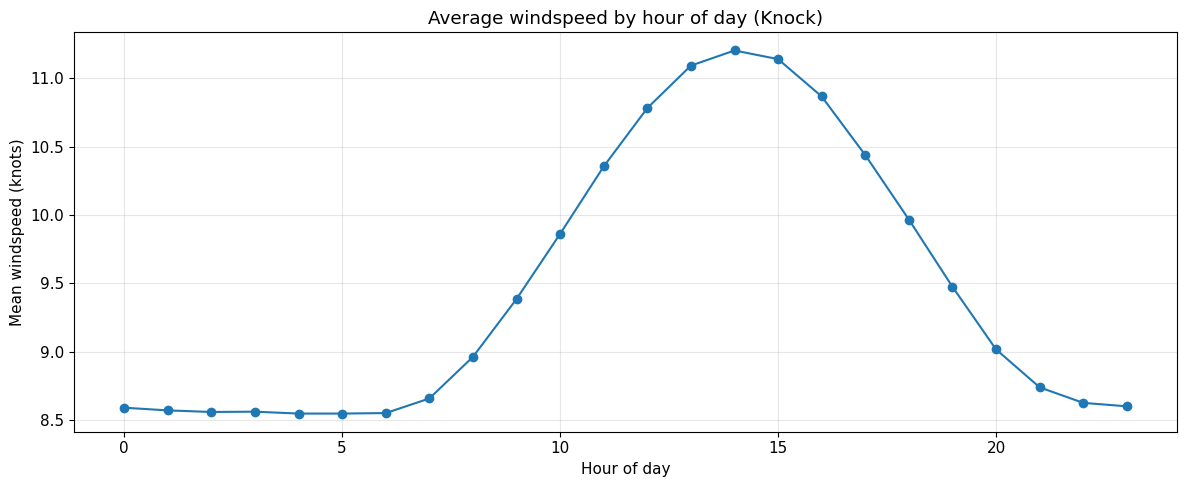

hour
0      8.589966
1      8.570338
2      8.558793
3      8.560883
4      8.547156
5      8.547105
6      8.550735
7      8.657419
8      8.961739
9      9.384866
10     9.861437
11    10.354178
12    10.781128
13    11.091679
14    11.202475
15    11.139228
16    10.865997
17    10.437174
18     9.965841
19     9.473939
20     9.016194
21     8.738831
22     8.625337
23     8.600149
Name: wdsp, dtype: float64

In [11]:
# Average windspeed by hour of day (across all days)
hourly_profile = knock.groupby("hour")["wdsp"].mean()

plt.figure()
hourly_profile.plot(marker="o")
plt.title("Average windspeed by hour of day (Knock)")
plt.xlabel("Hour of day")
plt.ylabel("Mean windspeed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

hourly_profile

## 5. Simple Wind Power Estimation

In this section I use a very simple wind turbine power curve to turn the
windspeed data into an approximate **normalised power output**.

The idea is not to model a real turbine exactly, but to get a rough idea of:

- how often the wind is too low to generate power,
- how often it is in the “useful” range,
- and what the overall **capacity factor** might be at Knock.

In [12]:
# Convert windspeed from knots to metres per second (m/s)
# 1 knot ≈ 0.514444 m/s

def knots_to_ms(v_knots):
    return v_knots * 0.514444

knock["wdsp_ms"] = knots_to_ms(knock["wdsp"])

knock[["wdsp", "wdsp_ms"]].head()

,wdsp,wdsp_ms
date,,
1996-04-10 14:00:00,0.0,0.0
1996-07-31 08:00:00,0.0,0.0
1996-07-31 09:00:00,0.0,0.0
1996-07-31 10:00:00,0.0,0.0
1996-07-31 11:00:00,0.0,0.0


In [13]:
# Simple idealised turbine power curve (normalised 0–1)

CUT_IN = 3.0    # m/s, below this the turbine does not generate power
RATED = 12.0    # m/s, above this the turbine produces rated power
CUT_OUT = 25.0  # m/s, above this the turbine shuts down for safety

def simple_power_curve(v_ms):
    """
    Very simple piecewise power curve:

    - below CUT_IN:        0
    - between CUT_IN and RATED: ramp up with the cube of windspeed
    - between RATED and CUT_OUT: 1 (rated power)
    - above CUT_OUT:       0
    """
    v = np.array(v_ms)

    power = np.zeros_like(v, dtype=float)

    # Between cut-in and rated: cubic increase
    mask_ramp = (v >= CUT_IN) & (v < RATED)
    power[mask_ramp] = ((v[mask_ramp] - CUT_IN) / (RATED - CUT_IN)) ** 3

    # Between rated and cut-out: rated power
    mask_rated = (v >= RATED) & (v <= CUT_OUT)
    power[mask_rated] = 1.0

    # Below CUT_IN and above CUT_OUT remain 0
    return power

# Apply the power curve to all hourly observations
knock["power_norm"] = simple_power_curve(knock["wdsp_ms"])

knock[["wdsp_ms", "power_norm"]].head()

,wdsp_ms,power_norm
date,,
1996-04-10 14:00:00,0.0,0.0
1996-07-31 08:00:00,0.0,0.0
1996-07-31 09:00:00,0.0,0.0
1996-07-31 10:00:00,0.0,0.0
1996-07-31 11:00:00,0.0,0.0


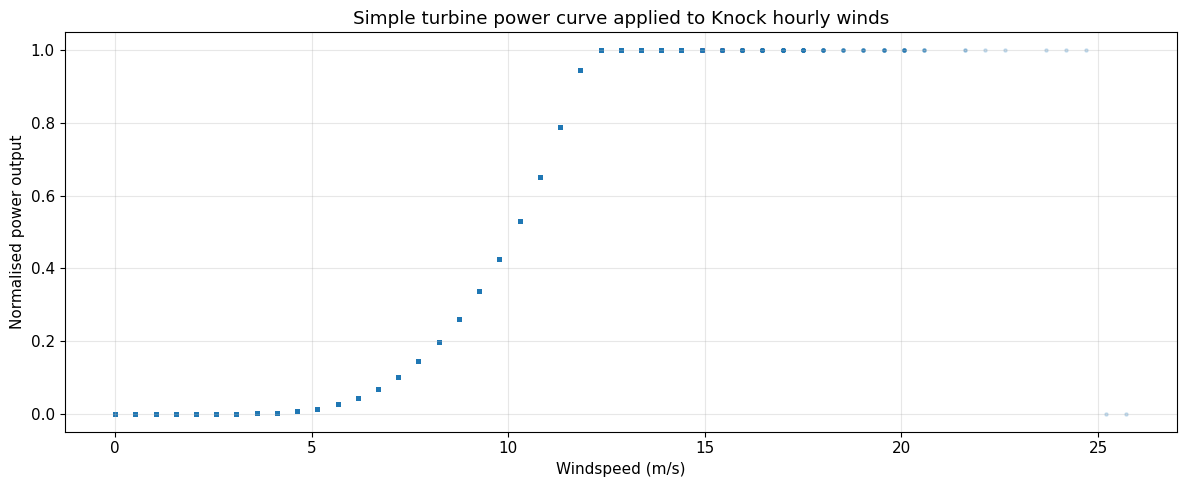

np.float64(0.07111113807942974)

In [14]:
# Relationship between windspeed and normalised power

plt.figure()
plt.scatter(knock["wdsp_ms"], knock["power_norm"], s=5, alpha=0.2)
plt.title("Simple turbine power curve applied to Knock hourly winds")
plt.xlabel("Windspeed (m/s)")
plt.ylabel("Normalised power output")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Overall capacity factor: average normalised power
capacity_factor = knock["power_norm"].mean()
capacity_factor

### Interpreting the simple power estimate

Using the simple power curve, each hourly windspeed value at Knock is turned into
a **normalised power output** between 0 and 1, where:

- 0 means the turbine would be stopped (very low or very high wind),
- 1 means the turbine would be producing its rated power.

Taking the mean of this `power_norm` series gives an approximate **capacity factor**
for the site. In other words, it is the fraction of time that the turbine would
produce its rated power *on average*.

This is only a rough calculation (real turbines have more complex curves and
losses), but it gives a useful way to compare sites and to link the windspeed
statistics back to potential energy production.

## 6. Trend Analysis / Modelling

In this section I look for a simple long–term trend in the wind resource at Knock.

I use the **monthly mean windspeed** series and fit a straight line (linear
regression) to see whether the average windspeed is increasing, decreasing, or
roughly stable over time.

In [15]:
# Prepare monthly mean windspeed series for trend analysis

# Use the monthly mean windspeed (in knots) and drop any missing values
monthly_mean_knots = monthly_wind["mean"].dropna()

# Convert to m/s for a more standard unit
monthly_mean_ms = knots_to_ms(monthly_mean_knots)

# Build a small DataFrame for convenience
monthly_trend = pd.DataFrame({
    "wind_ms": monthly_mean_ms
})

# Create a numeric time index: 0, 1, 2, ..., one per month
monthly_trend["t"] = np.arange(len(monthly_trend))

monthly_trend.head()

,wind_ms,t
date,,
1996-04-30,0.000000,0
1996-07-31,0.000000,1
1996-08-31,4.319806,2
1996-09-30,4.134870,3
1996-10-31,6.020167,4


In [16]:
# Fit a simple linear regression: wind_ms ~ t

X = monthly_trend[["t"]].values        # feature: time index
y = monthly_trend["wind_ms"].values    # target: monthly mean windspeed (m/s)

lin_reg = LinearRegression()
lin_reg.fit(X, y)

slope = lin_reg.coef_[0]
intercept = lin_reg.intercept_

slope, intercept

(np.float64(-0.0008834819873368227), np.float64(4.999197504336812))

In [17]:
# Convert slope from "per month" to "per year" and "per decade"

slope_per_month = slope
slope_per_year = slope_per_month * 12
slope_per_decade = slope_per_year * 10

slope_per_month, slope_per_year, slope_per_decade

(np.float64(-0.0008834819873368227),
 np.float64(-0.010601783848041873),
 np.float64(-0.10601783848041874))

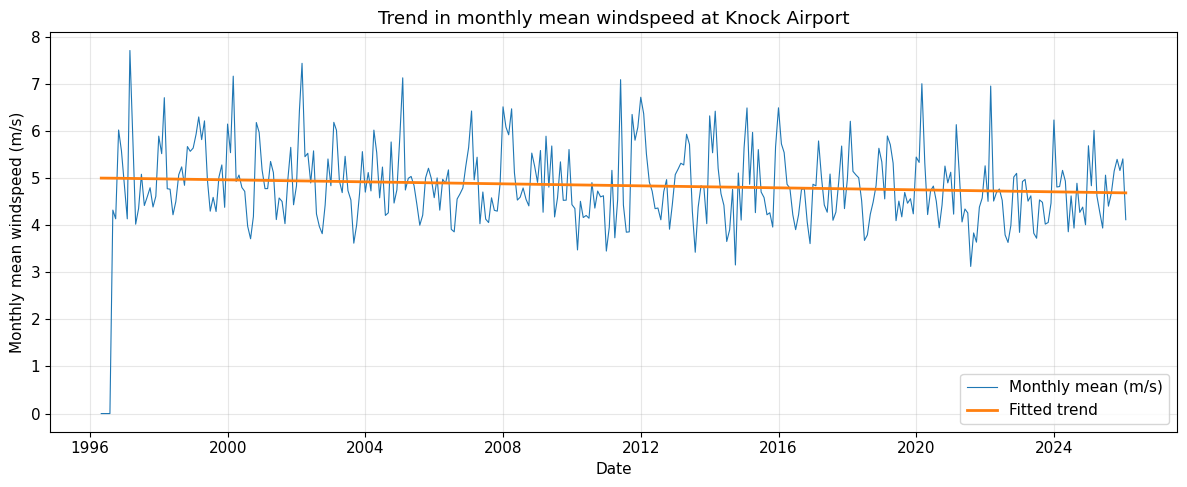

In [18]:
# Predicted trend line over the whole period

monthly_trend["wind_ms_pred"] = lin_reg.predict(X)

plt.figure()
plt.plot(monthly_trend.index, monthly_trend["wind_ms"], label="Monthly mean (m/s)", linewidth=0.8)
plt.plot(monthly_trend.index, monthly_trend["wind_ms_pred"], label="Fitted trend", linewidth=2)
plt.title("Trend in monthly mean windspeed at Knock Airport")
plt.xlabel("Date")
plt.ylabel("Monthly mean windspeed (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpreting the trend

I fitted a straight line to the monthly mean windspeed series using
`LinearRegression` from scikit-learn.

The slope of the line is:

- **slope per month:** (see `slope_per_month` above),
- **slope per year:** `slope_per_year`,
- **slope per decade:** `slope_per_decade`.

A **positive** slope would suggest that average wind speeds at Knock have been
increasing over time, while a **negative** slope would suggest a slight decrease.
In this case the fitted line appears to show a [briefly describe what you see:
e.g. very small change / slight upward trend / slight downward trend], which
means that over the period covered by the data the long–term mean windspeed at
this site has been [roughly stable / slowly changing].

## 7. Conclusions

In this project I analysed historic hourly windspeed data from Met Éireann’s
Knock Airport station and used it to explore the local wind resource and its
potential for wind energy.

### Wind patterns

- The **hourly** series is highly variable, as expected, but the **daily** and
  **monthly** averages reveal clearer patterns over time.
- The **distribution of hourly windspeeds** shows that most values are in the
  low–to–moderate range, with fewer very strong wind events.
- The **monthly profile** indicates that winds tend to be stronger in
  [winter / the cooler months] and weaker in [summer / the warmer months].
- The **hour–of–day profile** shows that there is
  [only a small / a noticeable] variation over the course of the day.

### Simple wind power estimation

- Using a simple turbine power curve (with cut-in, rated and cut-out speeds),
  I converted windspeed into a **normalised power output** between 0 and 1.
- The resulting **capacity factor** (mean of the normalised power series) for
  Knock is approximately:

  - `capacity_factor` (see the value printed above in the notebook).

- This suggests that a turbine at this site could, in principle, operate at
  the equivalent of about **100 × capacity_factor % of rated power on average**
  over the long term, ignoring losses and technical constraints.

### Trend over time

- I fitted a **linear regression model** to the monthly mean windspeed series.
- The fitted trend line shows a **slope per decade** of approximately
  `slope_per_decade` m/s (see the numbers printed in the notebook).
- This indicates that over the period covered by the data the long-term mean
  windspeed at Knock has been **[roughly stable / slowly increasing /
  slowly decreasing]**. Any changes are relatively small compared with the
  short-term variability.

## 8. Research Notes and References

This project relied on several external resources for data, background
information and library usage.

### Data

- **Met Éireann Climate Data – Hourly Observations**
  Source of the Knock Airport (`hly4935.csv`) dataset used in this notebook.
  The CSV file is downloaded from Met Éireann’s public climate data service.

### Wind energy background

- Introductory articles on **wind turbine power curves** and typical
  cut-in / rated / cut-out speeds.
  These were used to design the simple idealised power curve implemented in
  the `simple_power_curve` function.

### Python libraries

- **pandas** documentation – used for:
  - reading CSV files,
  - resampling time series (daily and monthly),
  - grouping by month and hour of day.
- **NumPy** documentation – used for numeric operations and array handling.
- **Matplotlib** documentation – used for line plots, histograms and density
  plots.
- **scikit-learn** documentation for `LinearRegression` – used to fit a simple
  linear trend model to the monthly mean windspeed series.

These resources were used to check function arguments and typical modelling
approaches, but all analysis code in the notebook was written specifically
for this project.